In [0]:
import requests
from IPython.core.display import HTML
# HTML(f"""
# <style>
# @import "https://cdn.jsdelivr.net/npm/bulma@0.9.4/css/bulma.min.css";
# </style>
# """)

# Descriptive Statistics and Handling Missing Data in Pose Data Sequences
This exercise descriptive statistics and managing missing data, particularly within a slightly intricate dataset comprising fixed-length skeleton data sequences. Moreover, it encompasses the evaluation of the efficacy of these methodologies.
The primary objective is to implement and scrutinize various techniques for managing absent data points, ensuring a comprehensive and unblemished dataset for subsequent analyses.
### Pose Data Overview
In the subsequent cell, the ground truth dataset is loaded alongside an identical yet noise-infused counterpart. This involves a 30-frame time series sequence, capturing human poses with each frame encompassing 25_2 features, namely the x and y coordinates for 25 skeletal joints. We'll generate 200 such sequences, forming a dataset with a shape of ( (200, 30, 25_2) ).
#### Handling Missing Values
From the ground truth dataset (`GT_poses`
), data has been intentionally omitted, thereby creating the `Noisy_poses`
 dataset wherein 30% of the original values have been randomly substituted with NaN values (`np.nan`
). The ensuing step involves implementing and evaluating varied strategies for dealing with these missing data points, ensuring the robustness of the eventual analyses derived from this dataset.

<article class="message">
    <div class="message-body">
        <strong>List of tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#filling_zeros">Task 1: Filling missing data - zeros</a>
            </li>
            <li>
            <a href="#mean_impute">Task 2: Mean imputer</a>
            </li>
            <li>
            <a href="#temp_interpolation">Task 3: Temporal interpolation</a>
            </li>
            <li>
            <a href="#evaluation">Task 4: Adjust data and evaluate</a>
            </li>
            <li>
            <a href="#method_comp">Task 5: Method comparison</a>
            </li>
            <li>
            <a href="#Mean">Task 6: Mean pose and pose sequence</a>
            </li>
            <li>
            <a href="#Correlation">Task 7: Correlation between features</a>
            </li>
        </ul>
    </div>
</article>



In [1]:
## Load the data 
# give a title - to this box
## import libraries
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn theme (handles most styling)
sns.set_theme(style="whitegrid")

# Optional: try to apply a Seaborn-like Matplotlib style if available
for candidate in ['seaborn-v0_8', 'seaborn-v0_8-whitegrid', 'seaborn-whitegrid', 'seaborn-darkgrid']:
    if candidate in plt.style.available:
        plt.style.use(candidate)
        break

# Set random seed for reproducibility
np.random.seed(42)


GT_poses  = np.load("data/Input_Poses.npy")
Noisy_poses = np.load('data/Noisy_poses.npy')

N,T,D,C = Noisy_poses.shape
GT_poses = GT_poses.reshape(N,T,D*C)
Noisy_poses = Noisy_poses.reshape(N,T,D*C)

Plotting functions are provided in the cell below. It is not required to understand or modify any of these functions to complete the exercise.


In [2]:
def limb_number_plot(s_pose_x,s_pose_y,n1,n2,c="red",label=None):
  if label is not None:
    if (s_pose_x[n1]>0) and (s_pose_x[n2]>0) and (s_pose_y[n1]>0) and (s_pose_y[n2]>0): 
      plt.plot([s_pose_x[n1],s_pose_x[n2]], [s_pose_y[n1], s_pose_y[n2]],color = c, linestyle="-",label=label)
  else:
    if (s_pose_x[n1]>0) and (s_pose_y[n1]>0):
       plt.plot(s_pose_x[n1], s_pose_y[n1],'*',color = c,label=label)
    if (s_pose_x[n2]>0) and (s_pose_y[n2]>0):
       plt.plot(s_pose_x[n2], s_pose_y[n2],'*',color = c,label=label)
    if (s_pose_x[n1]>0) and (s_pose_x[n2]>0) and (s_pose_y[n1]>0) and (s_pose_y[n2]>0):
      plt.plot([s_pose_x[n1],s_pose_x[n2]], [s_pose_y[n1], s_pose_y[n2]],color = c, linestyle="-")

def plot_single_pose(s_pose,c = "darkgreen",label=None,ds='body_25',c_head = 'red',head = True):
    
    s_pose_x=s_pose[::2]
    s_pose_y=s_pose[1::2]
    #torso/body
    limb_number_plot(s_pose_x,s_pose_y,2,5,c)
    if label is not None:

        limb_number_plot(s_pose_x,s_pose_y,9,12,c,label)
    else:
        limb_number_plot(s_pose_x,s_pose_y,9,12,c)
    limb_number_plot(s_pose_x,s_pose_y,2,9,c)
    limb_number_plot(s_pose_x,s_pose_y,5,12,c)

    #left arm (person facing away)
    limb_number_plot(s_pose_x,s_pose_y,2,3,c)
    limb_number_plot(s_pose_x,s_pose_y,3,4,c)

    #right arm
    limb_number_plot(s_pose_x,s_pose_y,5,6,c)
    limb_number_plot(s_pose_x,s_pose_y,6,7,c)

    #left leg / foot
    limb_number_plot(s_pose_x,s_pose_y,9,10,c)
    limb_number_plot(s_pose_x,s_pose_y,10,11,c)
    limb_number_plot(s_pose_x,s_pose_y,11,22,c)
    #right leg / foot
    limb_number_plot(s_pose_x,s_pose_y,12,13,c)
    limb_number_plot(s_pose_x,s_pose_y,13,14,c)
    limb_number_plot(s_pose_x,s_pose_y,14,19,c)

    # head
    if head:
        limb_number_plot(s_pose_x,s_pose_y,0,15,c)
        limb_number_plot(s_pose_x,s_pose_y,0,16,c)

        limb_number_plot(s_pose_x,s_pose_y,15,17,c)
        limb_number_plot(s_pose_x,s_pose_y,16,18,c)
    return True 

import math
import matplotlib.pyplot as plt

def plot_single_sequence(poses, pose_name='Poses', color='blue', max_cols=10):
    """
    Plot a sequence of skeleton poses (frames) in a grid layout.

    Parameters
    ----------
    poses : array-like
        Skeleton sequence data, shape (T, D).
    pose_name : str, optional
        Title prefix for each frame (default: 'Poses').
    color : str, optional
        Color of the skeleton (default: 'blue').
    max_cols : int, optional
        Maximum number of columns for subplots (default: 10).
    """
    T = len(poses)
    ncols = min(max_cols, max(1, T))
    nrows = math.ceil(T / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(2.0 * ncols, 2.0 * nrows))
    fig.suptitle(
        'Ground truth' if pose_name.lower() in ('gt', 'ground truth') else pose_name,
        y=0.98,
        fontsize=16
    )

    # Flatten axes to simplify iteration
    if not isinstance(axes, (list, tuple, np.ndarray)):
        axes = np.array([axes])
    axes = axes.ravel()

    for i in range(T):
        ax = axes[i]
        plt.sca(ax)
        plot_single_pose(poses[i], c=color, head=False)  # assumes you have this defined
        ax.set_ylim(1, 0)
        ax.set_xlim(-1, 1)
        ax.set_title(f"{pose_name}{i}", fontsize=10)
        ax.axis('off')

    # Hide extra axes if any
    for j in range(T, len(axes)):
        axes[j].axis('off')

    fig.tight_layout()
    plt.show()

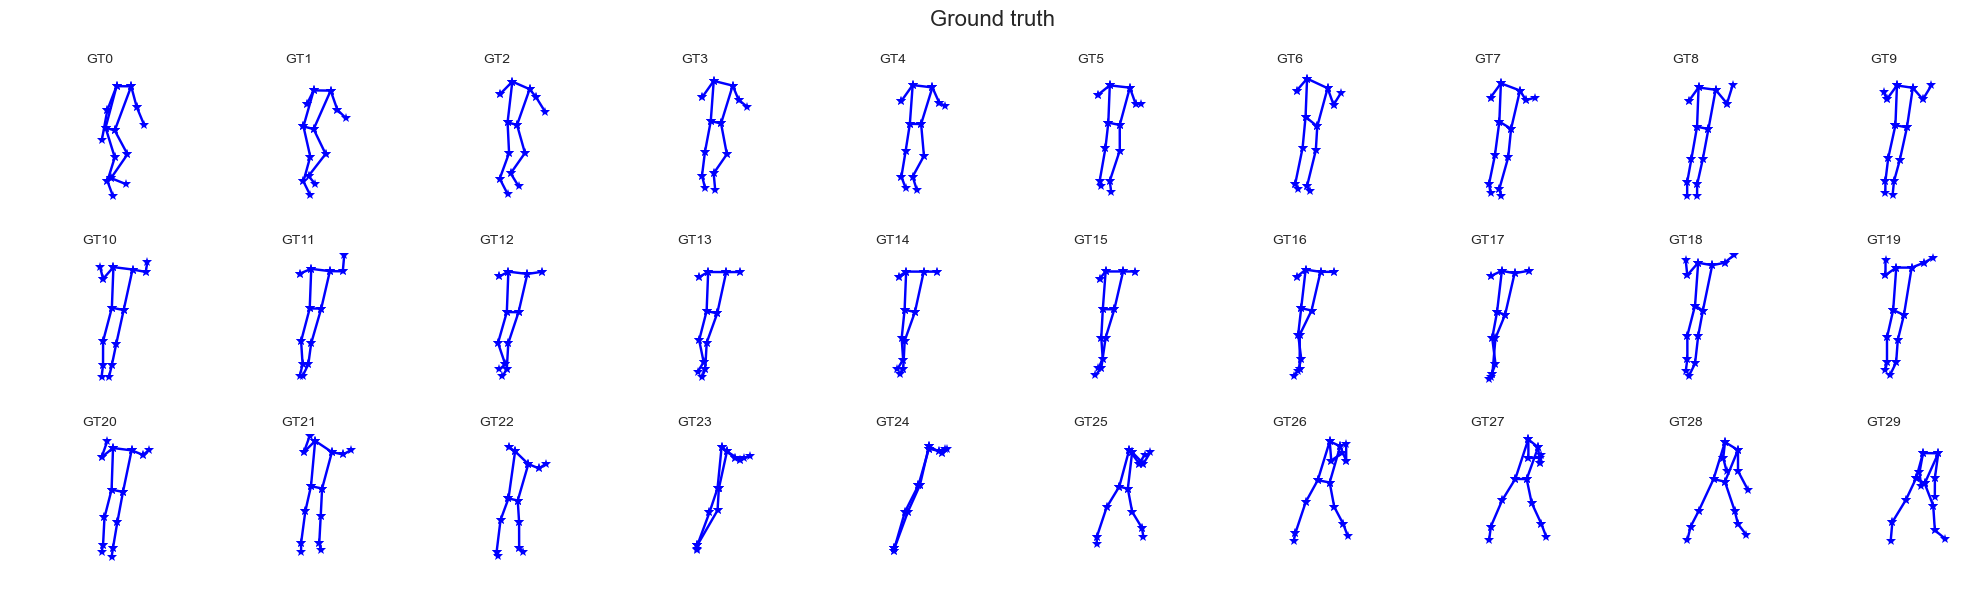

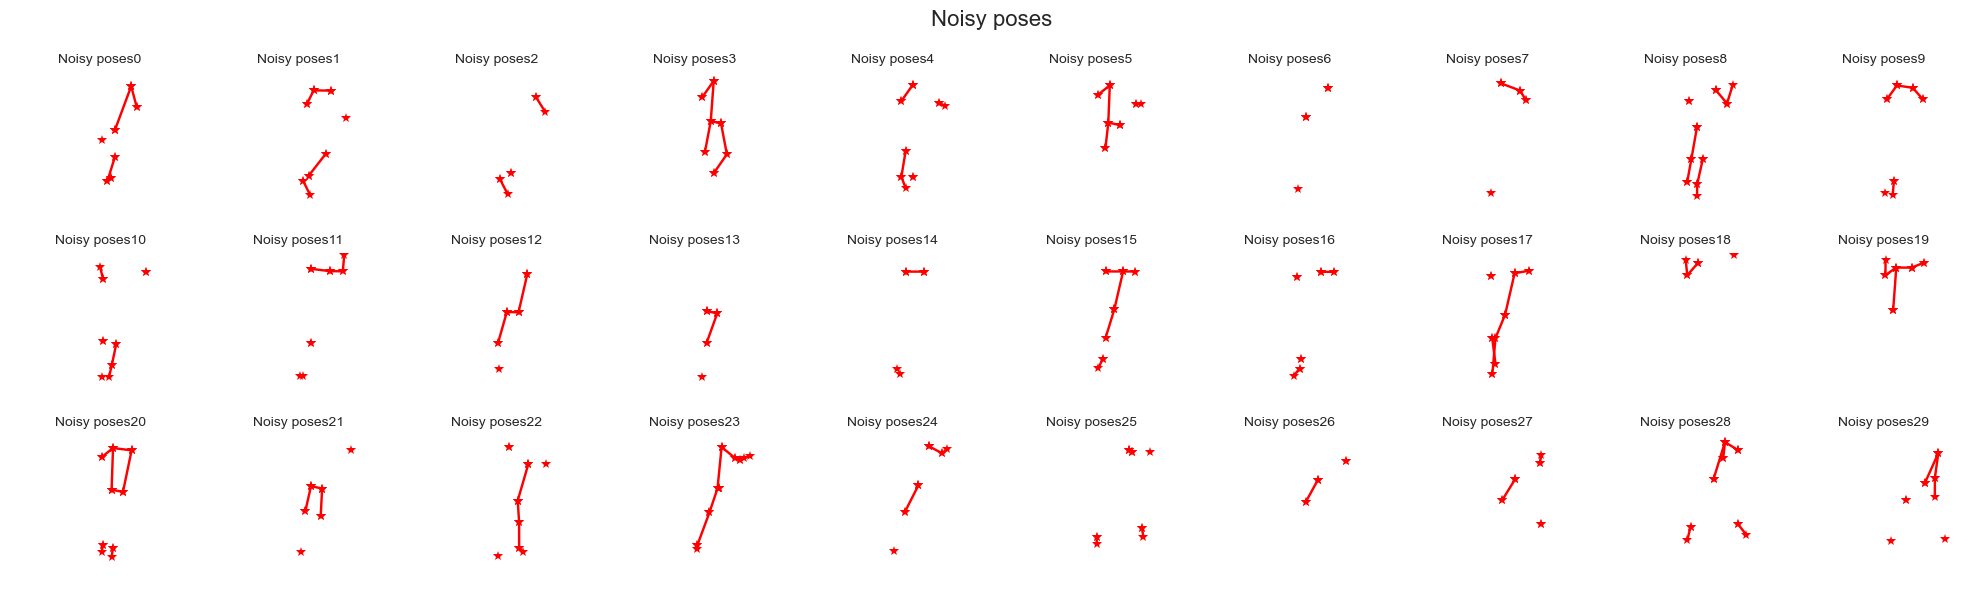

In [3]:
## Plot a random single sequence of both the noisy and ground truth skeleton data.
np.random.seed(12)
sample = np.random.randint(0,200)
plot_single_sequence(GT_poses[sample],pose_name='GT',color='blue')
plot_single_sequence(Noisy_poses[sample],pose_name='Noisy poses',color='red')

### Missing data strategies
In the following steps we will learn 3 different methods for handling missing data. 
1. Inserting zeros
2. Inserting means
3. Linear interpolation over time


---
**Task 1 (easy): Filling missing data - zeros👩‍💻**
Implement the first of 3 different methods for filling in missing data in the `Noisy_poses`
 in the cell below. The approach `filling_missing`
 should fill missing entries in the data sequences (`np.nan`
-values)with a zeros.
**Note:** (Hint: the function `np.isnan`
 can be used to find indices containing NaN values.)


---

In [4]:
## Method 1: Flling missing entries with 0s
def filling_missing(data):
    """
    Fills missing entries in the given data with a specified value.

    Parameters:
    - data (numpy.array): 3D numpy array with shape (num_samples, seq_len, num_features) containing data entries.
    - filling (int or float): The value used to fill missing entries.

    Returns:
    - numpy.array: Data with missing entries filled using the specified value.
    """
    #write code here ...
    filled_data = np.copy(data)
    filled_data[np.isnan(filled_data)] = 0
    return filled_data


---
**Task 2 (medium): Mean imputer👩‍💻**
Implement the `mean_imputer`
 function below. The function should contain:
- Extract `data`
 shape and create a copy, `imputed_data`
, for imputation.

- Loop through each feature in `imputed_data`
.

- Compute the mean, identify `np.nan`
 indices, and replace them with the mean.

- Ensure `imputed_data`
 is returned, with all `np.nan`
 entries imputed.



---

In [5]:
## Method 2: Mean impute
def mean_imputer(data):
    """
    Imputes missing entries in the given data using the mean value of the features.

    Parameters:
    - data (numpy.array): 3D numpy array with shape (num_samples, sequence_len, num_features) containing data entries.

    Returns:
    - numpy.array: Data with missing entries imputed using the mean value.
    """
    #write code here ...
    num_samples, seq_len, num_features = data.shape
    imputed_data = np.copy(data)

    for feature_idx in range(num_features):
        feature_data = imputed_data[:, :, feature_idx]
        mean_value = np.nanmean(feature_data) # Compute mean excluding `np.nan`
        nan_indices = np.isnan(feature_data)
        feature_data[nan_indices] = mean_value
        imputed_data[:, :, feature_idx] = feature_data

    assert not np.isnan(imputed_data).any(), "Imputation failed, NaN values remain."
    return imputed_data



---
**Task 3 (hard): Temporal interpolation👩‍💻**
Define the function `time_series_interpolation(data)`
 with `data`
 as a 3D numpy array input.
- Extract the shape of `data`
 and create a copy named `interpolated_data`
 to perform operations without altering the original data.

- Implement nested for-loops to iterate through each sample (i) and each feature (j) in `interpolated_data`
.

- Inside the nested loops:
    - Retrieve the time series sequence for the current sample and feature.
    - Handle cases for the first element being `np.nan`
 by finding the next available value in the sequence and imputing the `np.nan`
 using a suitable replacement logic.
    - Iterate through the time series (k), locating `np.nan`
 entries, and implementing logic to interpolate values, ensuring handling of consecutive `np.nan`
 entries.
    - Account for the scenario where the last element is `np.nan`
, replacing it with the second-to-last element.


- Have the function return `interpolated_data`
 with all `np.nan`
 entries interpolated.



---

In [56]:
## Mehtod 3:Temporal approach
def time_series_interpolation(data):
    """
    Performs time series interpolation to fill missing entries in the given data.

    Parameters:
    - data (numpy.array): 3D numpy array with shape (num_samples, sequence_len, num_features) containing data entries.

    Returns:
    - numpy.array: Data with missing entries filled using time series interpolation.
    """
    #write code here ...
    # num_samples, seq_len, num_features = data.shape
    # interpolated_data = np.copy(data)

    # for i in range(num_samples): # Iterate over each sample i
    #     for j in range(num_features): # Iterate over each feature j
    #         time_series = interpolated_data[i, :, j] # Get the time series for sample i and feature j

    #         if np.isnan(time_series[0]): # If the first element is NaN
    #             for k in range(1, seq_len):
    #                 if not np.isnan(time_series[k]):
    #                     time_series[0] = time_series[k] # Impute with the next available value
    #                     break

    #         for k in range(1, seq_len - 1):
    #             if np.isnan(time_series[k]):
    #                 prev_value = time_series[k - 1] 
    #                 next_value = None
    #                 for m in range(k + 1, seq_len):
    #                     if not np.isnan(time_series[m]):
    #                         next_value = time_series[m]
    #                         break
    #                 if next_value is not None:
    #                     time_series[k] = (prev_value + next_value) / 2 # NaN-value imputed as average of previous and next values
    #                 else:
    #                     time_series[k] = prev_value # If no next value, carry forward the previous value (also handles if at end)

    #         interpolated_data[i, :, j] = time_series

    # assert not np.isnan(interpolated_data).any(), f"Interpolation failed, NaN values remain. {np.isnan(interpolated_data).sum()} NaNs found."
    # return interpolated_data







    # Extract shape and create a copy
    num_samples, sequence_len, num_features = data.shape
    interpolated_data = np.copy(data)

    # Iterate through samples and features
    for i in range(num_samples):
        for j in range(num_features):
            # Extract the time series for sample i and feature j
            series = interpolated_data[i, :, j]

            # Handle case where the entire series is NaN
            if np.isnan(series).all():
                # Prefer filling with the per-time-step mean across other samples for this feature if available
                mean_time = np.nanmean(data[:, :, j], axis=0)  # Mean across samples for each time step (shape: (sequence_len,)).
                if np.isnan(mean_time).all():
                    # If the whole feature is NaN across the dataset, fallback to global mean
                    global_mean = np.nanmean(data[:, :, j]) # global mean is the mean of the feature across all samples and time steps
                    if np.isnan(global_mean):
                        # If even global mean is NaN, fill with zeros
                        series[:] = 0.0
                    else:
                        series[:] = global_mean
                else:
                    series[:] = mean_time
                interpolated_data[i, :, j] = series
                continue

            # Handle case where the first element is NaN
            if np.isnan(series[0]):
                # Find the first non-NaN value
                for k in range(1, sequence_len):
                    if not np.isnan(series[k]):
                        series[0] = series[k] # Impute with the next available value
                        break

            k = 1
            while k < sequence_len:
                if np.isnan(series[k]):
                    # Start of NaN block 
                    start_idx = k - 1
                    start_val = series[start_idx]

                    # Find the end of the NaN block
                    end_idx = k
                    while end_idx < sequence_len and np.isnan(series[end_idx]):
                        end_idx += 1

                    if end_idx == sequence_len: # if NaNs reach the end (the last elements are NaN)
                        series[k:sequence_len] = start_val # Impute with last valid value
                        break
                    else:
                        # Interpolate between start_val and end_val
                        end_val = series[end_idx]
                        gap = end_idx - start_idx

                        for n in range(1, gap):
                            series[start_idx + n] = start_val + (end_val - start_val) * (n / gap)

                        k = end_idx
                else:
                    k += 1

            # Assign back to interpolated data
            interpolated_data[i, :, j] = series

    return interpolated_data

### Apply and evaluate approaches
#### Error function (MSE)
The function  `MSE`
 that find the mean squared error between the adjusted and ground truth data.
- the MSE can be averaged across different dimensions of the skeleton pose data array such that average loss across each step of the time seqeunce ('Temporal') or the loss across each joints/features ('Joint') is calculated.


In [71]:
def MSE(Noisy,GT,avg='Temporal'):
    loss = (Noisy - GT) ** 2
    if avg=='Temporal':
        loss = loss.mean(axis=(0,2))
    elif avg == "Joint":
        loss = loss.mean(axis=(0,1))
    else:
        loss  = loss.mean()
    return loss


---
**Task 4 (easy): Adjust data and evaluate👩‍💻**
Evaluate the performance of each imputation approach by comparing the adjusted data to the ground truth seqeunces using the `MSE`
 function. The task is done in the following steps.
1. Adjust the noisy data with an imputation method.
2. Calculate the _mean squared error_ between the adjusted and ground truth poses, by using the function `MSE`
. 
3. Repeat for the remaining methods.


---

In [74]:
### Apply the 3 missing data measures to the noisy data and calculate their respective MSE
##example
adjusted_data1 = filling_missing(Noisy_poses)
error1 = MSE(adjusted_data1,GT_poses,avg='None')
print(f'The MSE of the data adjusted with filling in zeros: {error1}')

adjusted_data2 = mean_imputer(Noisy_poses)
error2 = MSE(adjusted_data2,GT_poses,avg='None')
print(f'The MSE of the data adjusted with mean imputer: {error2}')

adjusted_data3 = time_series_interpolation(Noisy_poses)
error3 = MSE(adjusted_data3,GT_poses,avg='None')
print(f'The MSE of the data adjusted with time series interpolation: {error3}') #OBS this result is different from Dans, but i belive there might be an error in his code


The MSE of the data adjusted with filling in zeros: 0.053628125275375645
The MSE of the data adjusted with mean imputer: 0.003934403174169293
The MSE of the data adjusted with time series interpolation: 0.0013447281272547678


### Plotting
#### Plot error distances
In the cell below, the MSE is plotted between the ground truth and adjusted poses, averaging both over the joints and the temporal sequence.


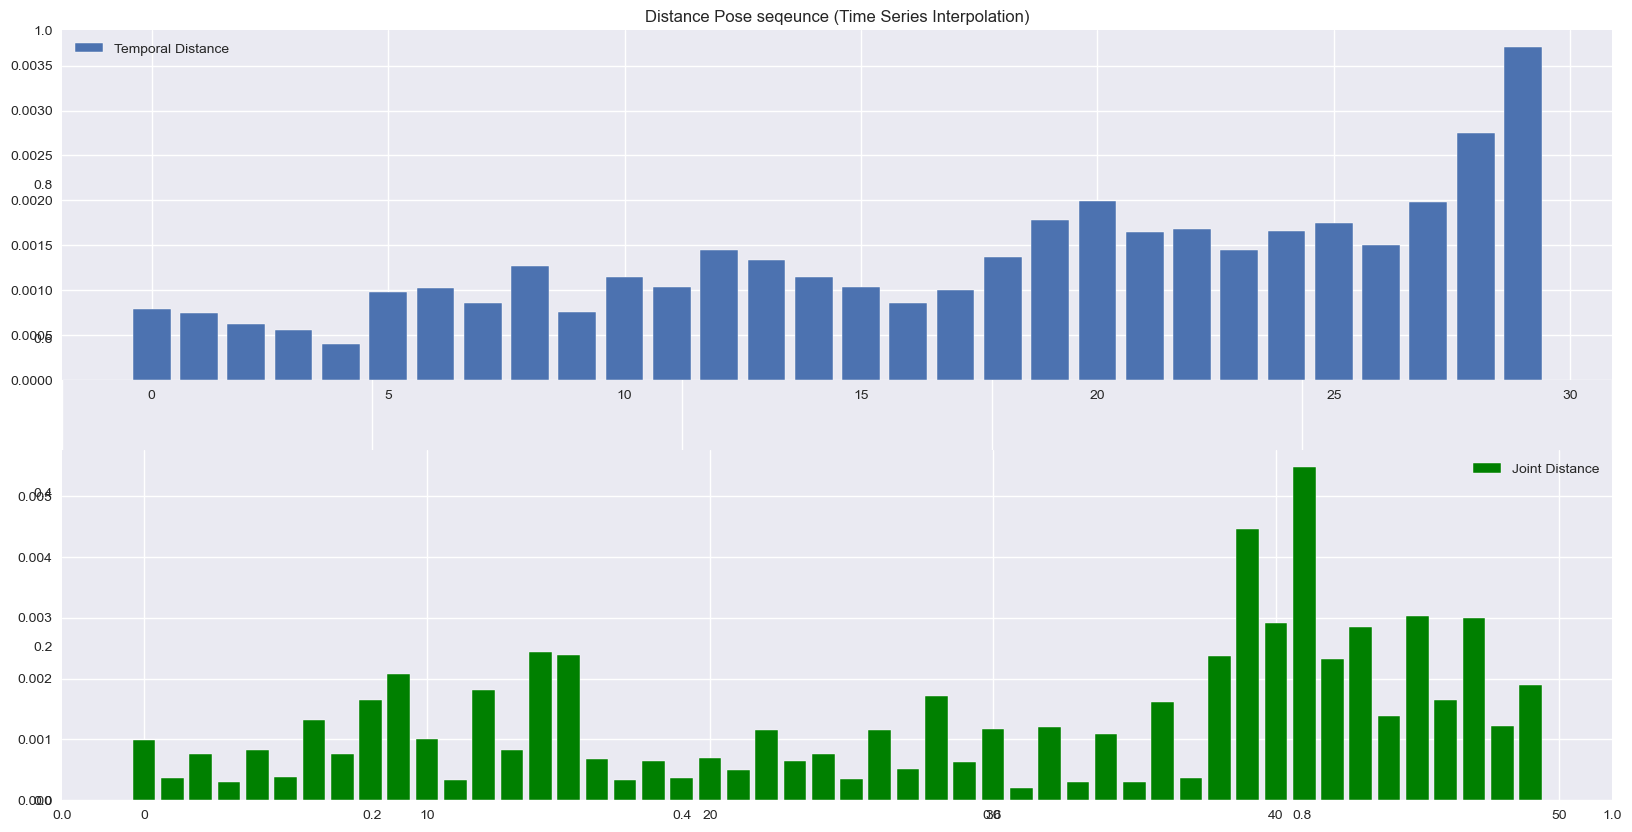

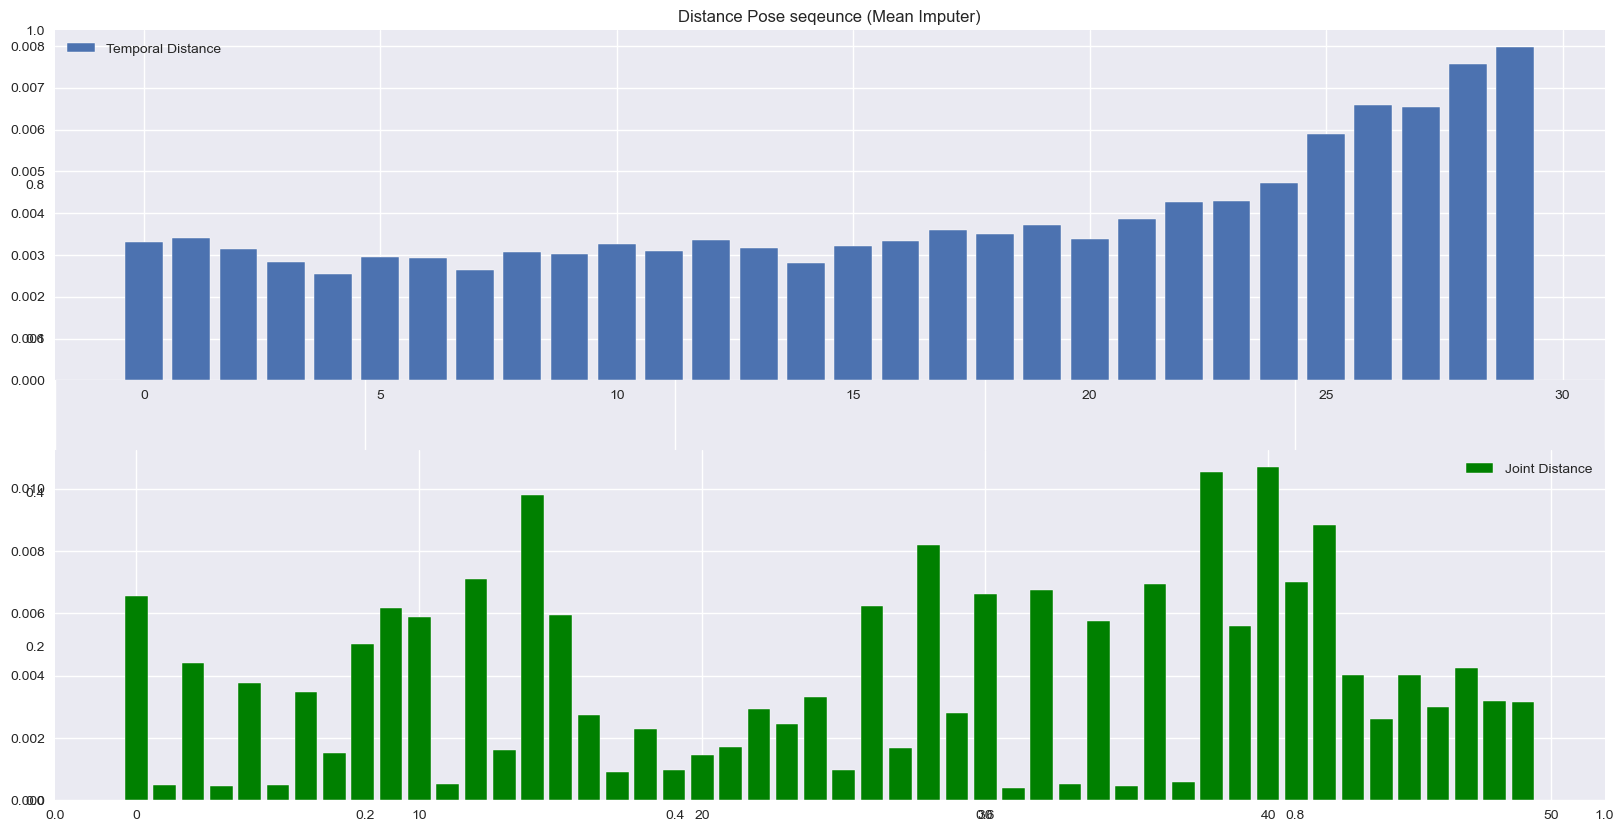

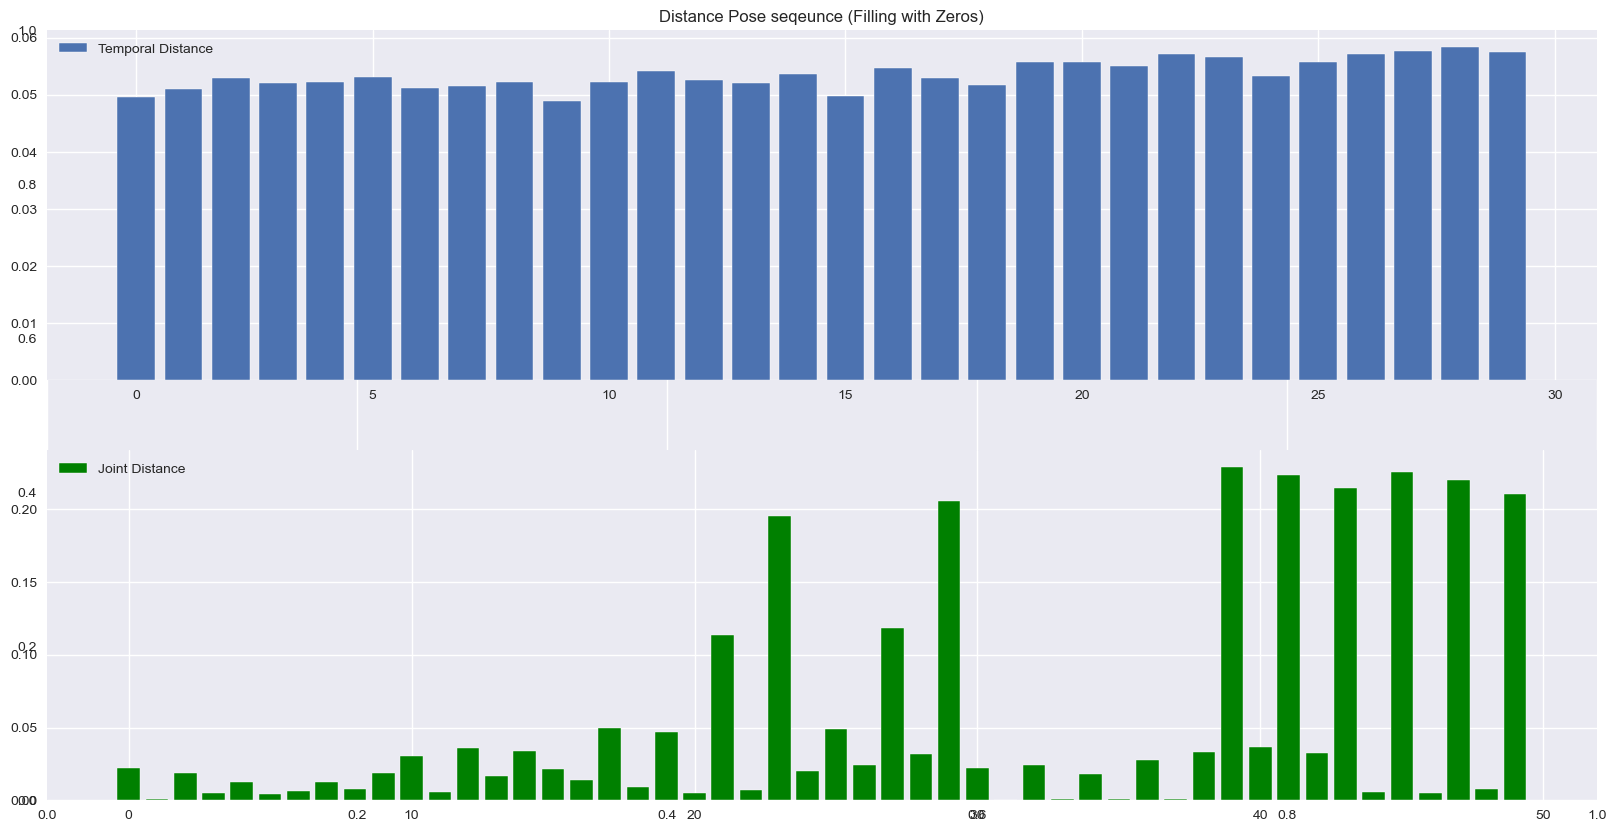

In [75]:
## Your should only run this cell after completing the exercise above
Dist1 = MSE(adjusted_data3,GT_poses,avg='Temporal')
plt.figure(figsize=(20,10))
plt.title('Distance Pose seqeunce (Time Series Interpolation)')
plt.subplot(2,1,1)
plt.bar(np.arange(len(Dist1)), Dist1, align='center',label='Temporal Distance')
plt.legend()
plt.subplot(2,1,2)
Dist2 = MSE(adjusted_data3,GT_poses,avg='Joint')
plt.bar(np.arange(len(Dist2)), Dist2, align='center',color='green',label='Joint Distance')
plt.legend()


# Include plots for the other two methods as well.
#Mean imputer:
Dist1_mean = MSE(adjusted_data2,GT_poses,avg='Temporal')
plt.figure(figsize=(20,10))
plt.title('Distance Pose seqeunce (Mean Imputer)')
plt.subplot(2,1,1)
plt.bar(np.arange(len(Dist1_mean)), Dist1_mean, align='center',label='Temporal Distance')
plt.legend()
plt.subplot(2,1,2)
Dist2_mean = MSE(adjusted_data2,GT_poses,avg='Joint')
plt.bar(np.arange(len(Dist2_mean)), Dist2_mean, align='center',color='green',label='Joint Distance')
plt.legend()

#Zero filling:
Dist1_zeros = MSE(adjusted_data1,GT_poses,avg='Temporal')
plt.figure(figsize=(20,10))
plt.title('Distance Pose seqeunce (Filling with Zeros)')
plt.subplot(2,1,1)
plt.bar(np.arange(len(Dist1_zeros)), Dist1_zeros, align='center',label='Temporal Distance')
plt.legend()
plt.subplot(2,1,2)
Dist2_zeros = MSE(adjusted_data1,GT_poses,avg='Joint')
plt.bar(np.arange(len(Dist2_zeros)), Dist2_zeros, align='center',color='green',label='Joint Distance')
plt.legend() 

#### Plotting GT, noisy and adjusted poses


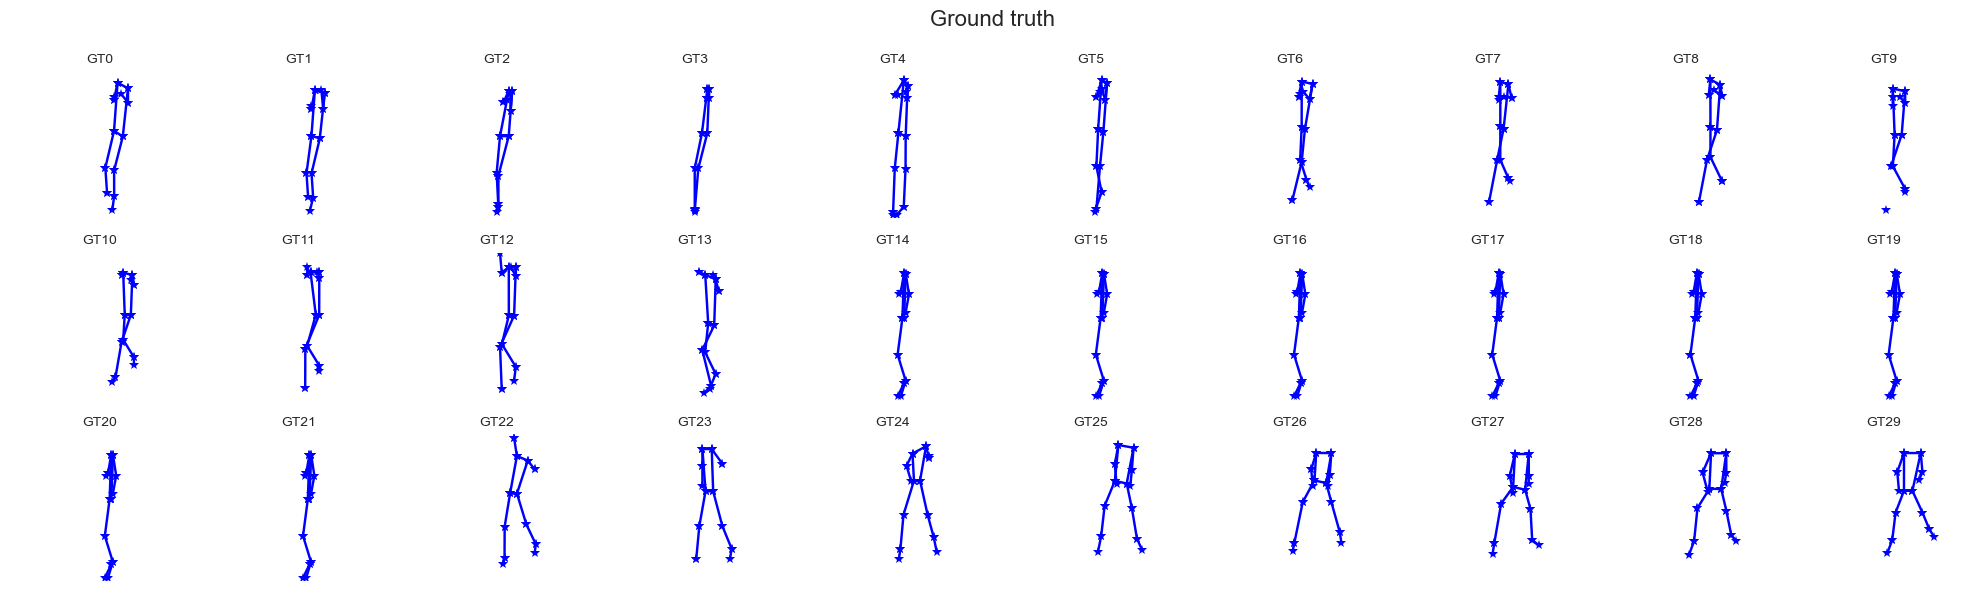

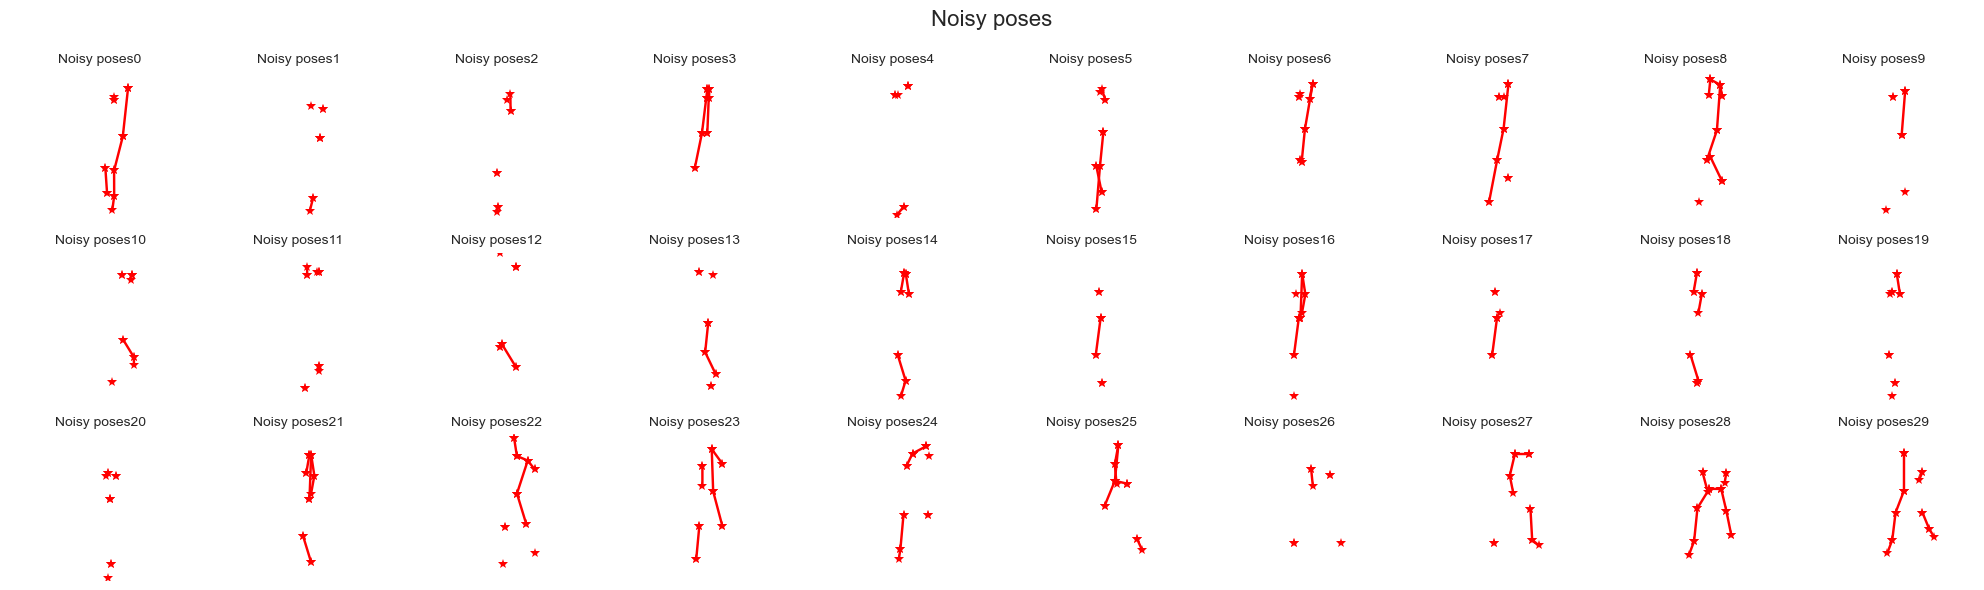

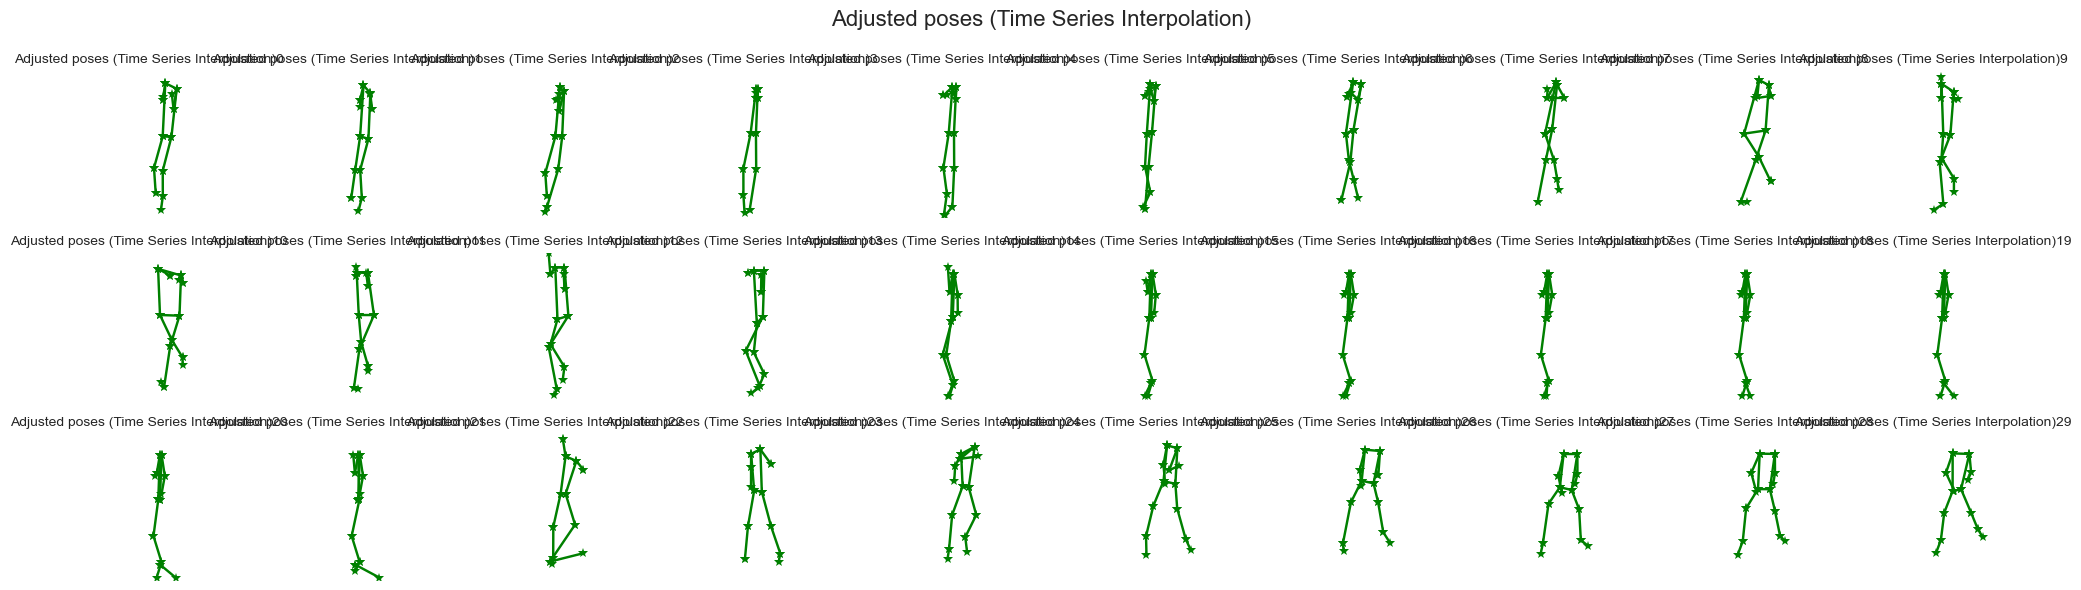

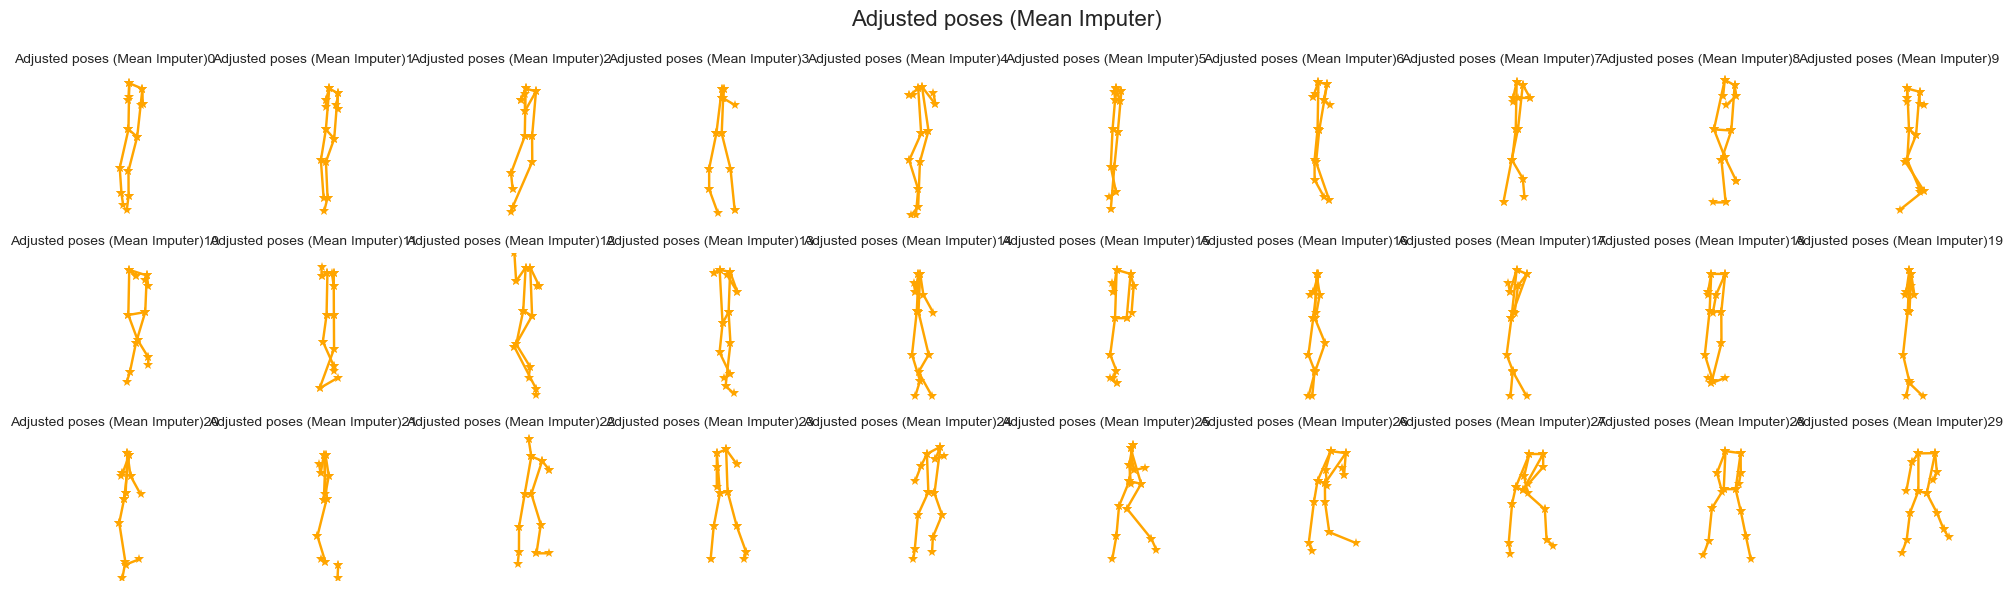

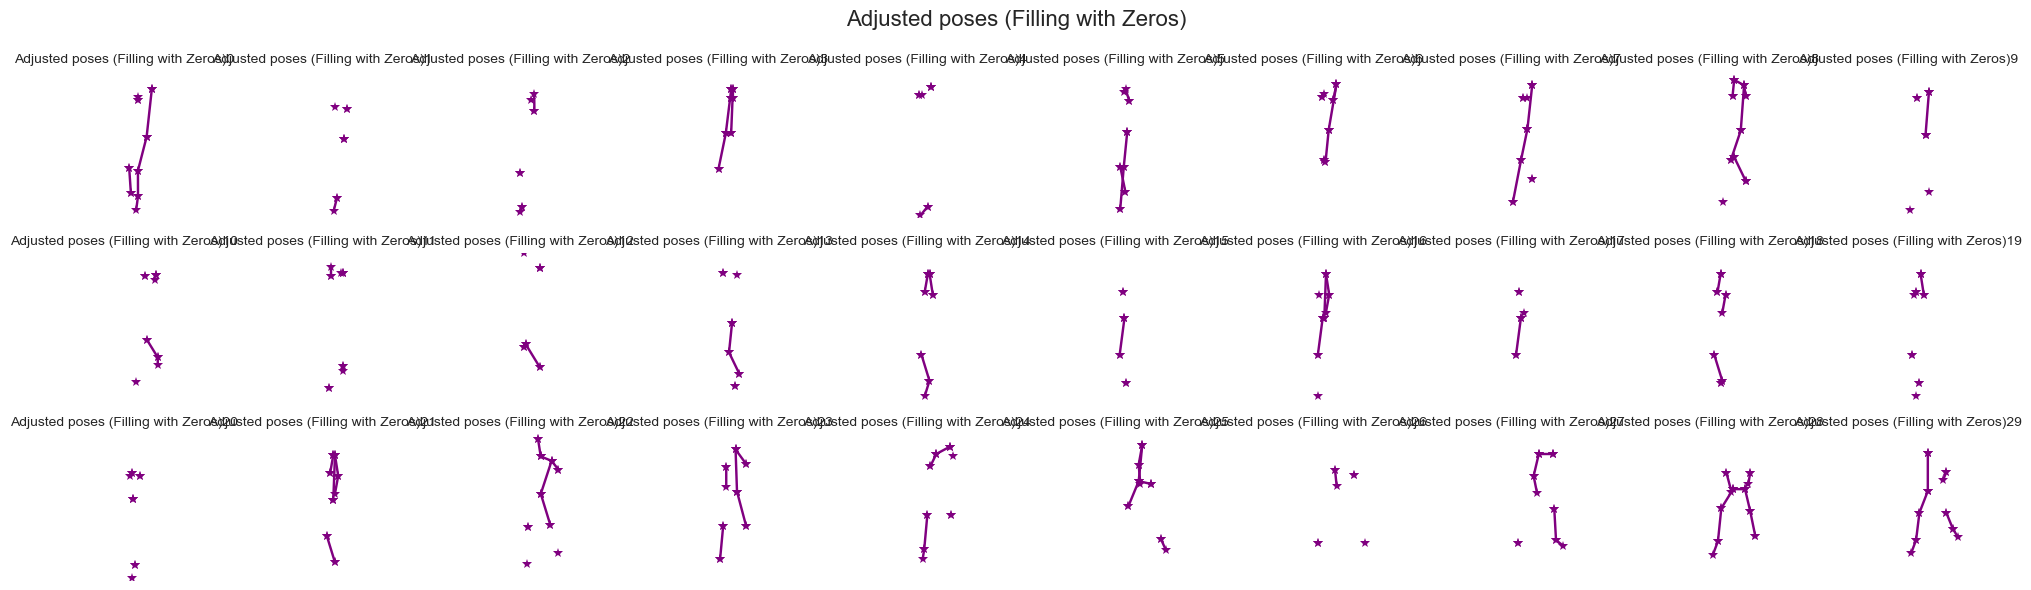

In [60]:
## Your should only run this cell after completing the exercise above
## Plot a random single sequence of the noisy, ground truth and adjusted skeleton data.
np.random.seed(42)
sample = np.random.randint(0,200)
plot_single_sequence(GT_poses[sample],pose_name='GT',color='blue')
plot_single_sequence(Noisy_poses[sample],pose_name='Noisy poses',color='red')
plot_single_sequence(adjusted_data3[sample],pose_name='Adjusted poses (Time Series Interpolation)',color='green')
plot_single_sequence(adjusted_data2[sample],pose_name='Adjusted poses (Mean Imputer)',color='orange')
plot_single_sequence(adjusted_data1[sample],pose_name='Adjusted poses (Filling with Zeros)',color='purple')


---
**Task 5 (medium): Method comparison💡📽️**
1. Analyze the mean squared error (MSE), and inspect the adjusted pose sequences for each missing data approach and discuss the advantages and disadvantages of each method.


---

In [0]:
# Write your answers here

# Temporal vs Joint MSE:
# From the bar plots, we can observe the differences in MSE values for each missing data handling method.
# Temporal MSE averages over samples and features, leaving one value per time step.
# This is usefull to inspect error evolution across time (which frames are more difficult to reconstruct).
# Joint MSE averages over samples and time steps, leaving one value per feature.
# This is usefull to inspect which joints/features are more difficult to reconstruct.
# Generally, lower MSE values indicate better performance in reconstructing the missing data.

# In the above pose-plots, we see the effects of the three different missing data handling methods: 
# green: linear interpolation over time, 
# orange: inserting means,
# purple: inserting zeros.

# Inserting zeros:
# Advantages: Simple and fast to implement. Does not require additional computations. Does not introduce new made-up values, and thus makes it clear where data was missing.
# Disadvantages: Zeroes are not really representative for the missing data, and does not really help the model to learn the underlying patterns.
# We see that the purple adjusted poses are not adding any visual improvement compared to the noisy data (red).
# In the MSE plots, 
# we see that the bars are all high in the temporal MSE plot, indicating that all time steps are affected.
# In the joint MSE plot, we see that some joints/features have very high bars, and other has low bars. 
# This indicate that specific features are more affected by the zero-filling than others.
# Since some features (points in the skeleton) might generally be closer to zero, they are less affected by zero-filling.

# Mean imputer:
# Advantages: Simple to implement and computationally efficient. Provides a reasonable estimate for missing values, especially when the data is missing at random.
# Disadvantages: Can introduce bias, especially if the data is not missing at random. Reduces variability in the data, which can affect model performance.
# We see that the orange adjusted poses are much more complete than the purple ones, and are visually closer to the ground truth (blue).
# But where the purple figures let everything unknown (NaN) up to imagination, the orange figures give a more consistent shape, and gives the impression of more knowledge, even though some of it is far from the truth.
# The MSE is lower than for the zero-filling, indicating better performance.
# In the MSE plots,
# the temporal MSE bars are lower than for the zero-filling, indicating the better performance of different frames. 
# A few of the frames still have pretty high bars, specifically the ones furthest to the right.
# In the joint MSE plot, we see a similar pattern as for the zero-filling,
# where some joints/features have very high bars, and other has low bars, 
# but there are more in the middle-range compared to the zero-filling.
# This indicate that more features are somewhat affected by the mean-imputer, but not as extremely as for the zero-filling. 
# The errors are distributed more evenly across features.

# Time series interpolation:
# Advantages: Utilizes the temporal structure of the data to provide more accurate estimates for missing values. Preserves trends and patterns in the data.
# Disadvantages: More complex to implement and computationally intensive. May not perform well if large blocks of data are missing.
# We see that the green adjusted poses are visually the closest to the ground truth (blue), 
# indicating that the time series interpolation method is effective in reconstructing the missing data.
# The MSE is the lowest among the three methods, indicating the best performance.
# In the MSE plots,
# the temporal MSE bars are generally low, indicating that most frames are well reconstructed.
# Like wiith the mean-imputer, a few of the frames still have higher bars, specifically the ones furthest to the right.
# This indicates that some frames are more challenging to reconstruct, possibly due to larger gaps in the data.
# In the joint MSE plot, we see only very few joints/features with high bars,
# indicating that most features are well reconstructed.
# Overall, the time series interpolation method appears to be the most effective in handling missing data in this context.


### Descriptive statistics for evaluating imputation method
As a final step, we need to evaluate how the missing value imputation procedure affects the statistical properties of the data. Specifically, we will focus on the mean and the covariance of both the original and the imputed poses.

---
**Task 6 (medium): Mean pose and pose sequence👩‍💻💡📽️**
The cell below contains code for plotting the original mean pose sequence. First run the cell, then modify the code to:
- Plot the mean sequence after filling in the missing values with zeros.
- Compare the two plots. Do you observe any differences? If yes, what could be the reason behind these differences and what insights can they provide regarding the characteristics of the mean?
- Plot the mean pose (not a sequence of poses, but a single pose) for the ground truth data and for the imputed datasets as well. Do you observe any differences between the mean pose (or the scale of the pose) in any of the plots?
- Based on the way in which the mean is calculated, is the mean sequence of poses or the mean pose more affected by the imputation process for missing data?


---

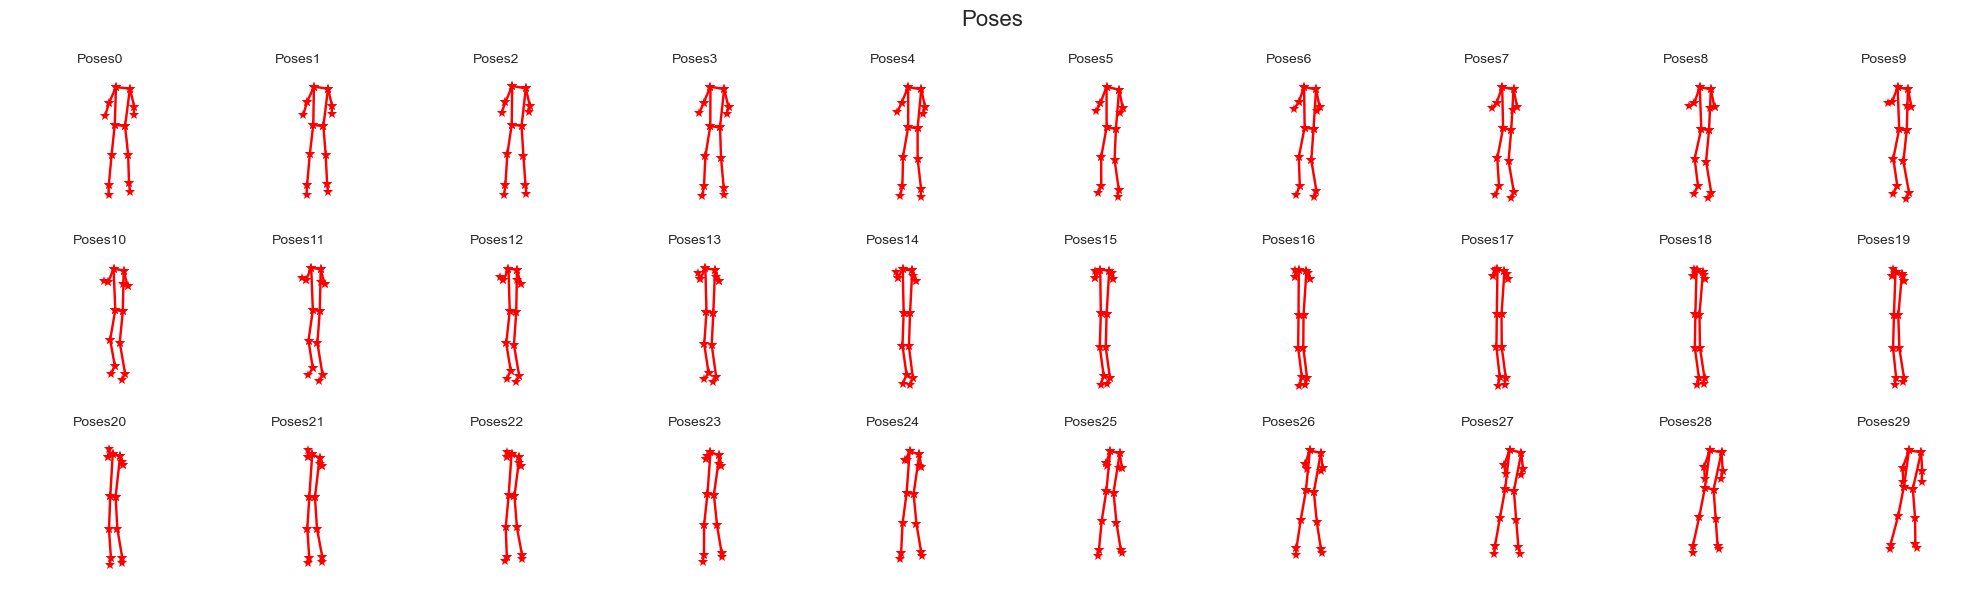

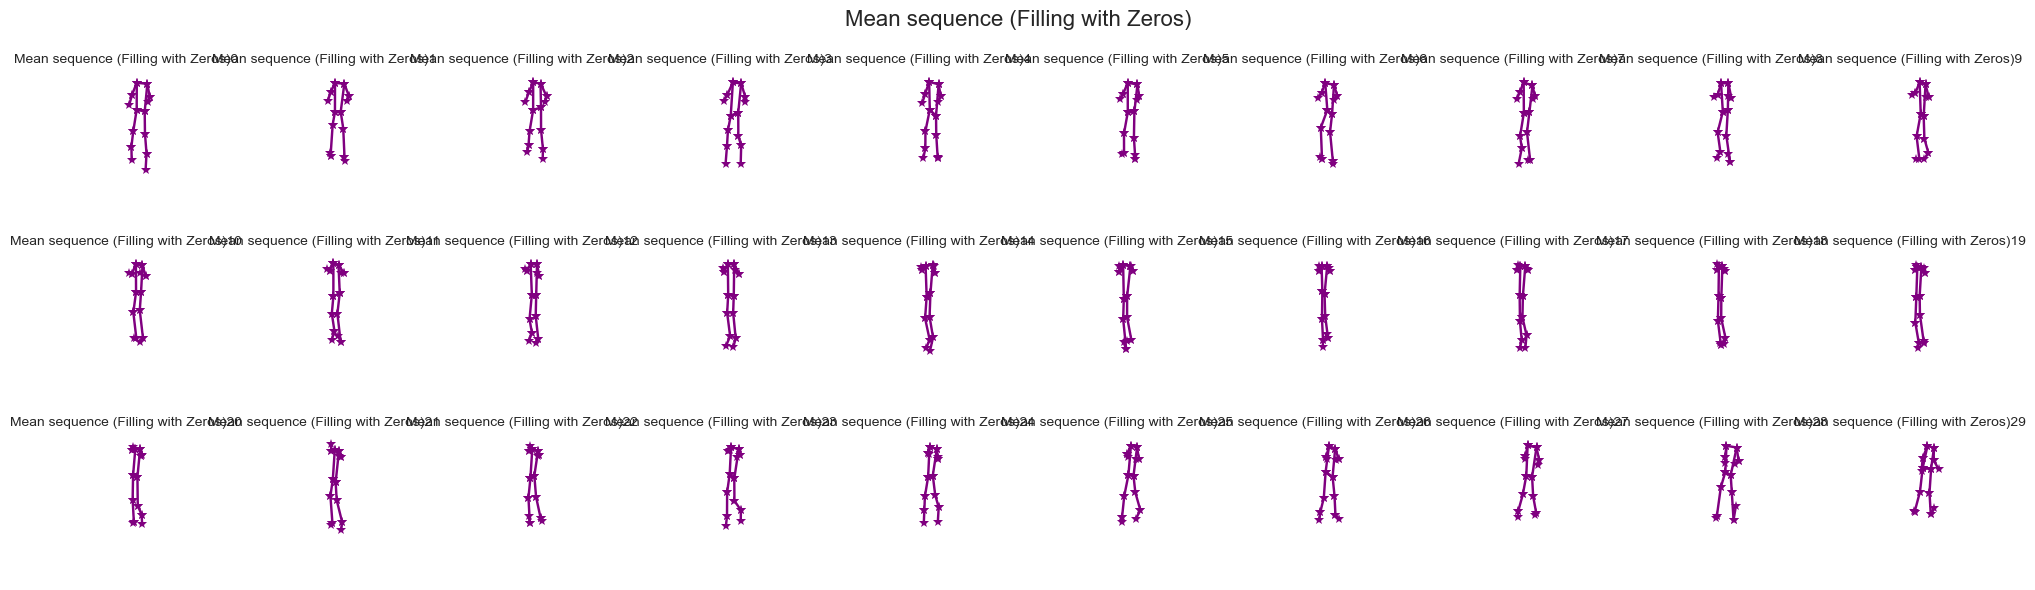

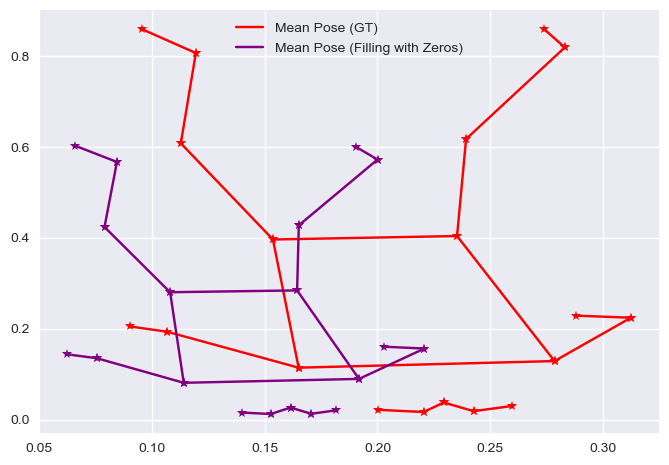

In [98]:
## Plotting the mean sequence
plot_single_sequence(GT_poses.mean(axis=(0)),color='red')

# Your solution goes here
# - Plot the mean sequence after filling in the missing values with zeros.
plot_single_sequence(adjusted_data1.mean(axis=(0)),color='purple',pose_name='Mean sequence (Filling with Zeros)')

# - Compare the two plots. Do you observe any differences? If yes, what could be the reason behind these differences and what insights can they provide regarding the characteristics of the mean?
# Yes, there are differences between the mean sequence of the ground truth data and the mean sequence after filling in missing values with zeros. 
# Generally, the purple poses (with zero-filling) appear to be more compressed or closer to the origin compared to the red poses (ground truth mean).
# This is because filling missing values with zeros introduces a bias towards the origin,
# which affects the overall mean calculation, pulling it closer to zero.

# - Plot the mean pose (not a sequence of poses, but a single pose) for the ground truth data and for the imputed datasets as well. 
plot_single_pose(GT_poses.mean(axis=(0, 1)),c='red',label='Mean Pose (GT)')
plot_single_pose(adjusted_data1.mean(axis=(0, 1)),c='purple',label='Mean Pose (Filling with Zeros)')
plt.legend()
# Do you observe any differences between the mean pose (or the scale of the pose) in any of the plots?
# Yes, the mean pose after filling in missing values with zeros (purple) appears to be more compressed or closer to the origin compared to the mean pose of the ground truth data (red).
# This was also observed in the mean sequence plots.
# The zero-filling method introduces a bias towards the origin, which affects the overall mean pose calculation, pulling it closer to zero.

# - Based on the way in which the mean is calculated, is the mean sequence of poses or the mean pose more affected by the imputation process for missing data?
# Mean sequence = per-frame mean across samples (shape T×D).
# Mean pose = single average pose (mean across samples and time(frames) → D).
# The mean sequence is more affected by imputation. 
# Reason: it computes a separate average for each time step, so any imputation bias that is concentrated at particular frames 
# (many NaNs filled with 0 in same frame) shows up directly as spikes/bias in that frame’s mean. 
# The mean pose averages over time as well, so frame-local biases get diluted.



In addition to analyzing the data's mean, we also need to investigate how the different imputation methods impact the relationship between variables. The tutorial demonstrated that correlation matrices are useful for quantifying how multiple variables co-vary. Throughout the next task we generate multiple correlation matrices to examine whether the relationship between features/joints is preserved by the way we handled missing data:

---
**Task 7 (easy): Correlation between features👩‍💻💡📽️**
This task is divided into multiple steps, as we need to construct and compare multiple correlation matrices:

**Info**
In the tutorial the correlation matrix was generated using the corr() function, which is exclusively applicable to Pandas DataFrames. In the current exercises we are working with a Numpy array. The correlation matrix for such an array can be obtained using the np.corrcoef() function.


The cell below contains code for pre-processing the ground truth dataset and constructing the correlation matrix:
1. Run the code and modify it to obtain a correlation matrix for each of the imputed datasets.
2. Compare the correlation matrices:    
    - Do any of the imputation methods preserve the original relationships between joints?
    - Does it have any significance whether the original relationship is preserved?


3. Based on the MSE scores, the visual inspection, and the inspection of statistical properties, which imputation method would you chose for the current dataset and why? List at least 5 different reasons for your choice.


---

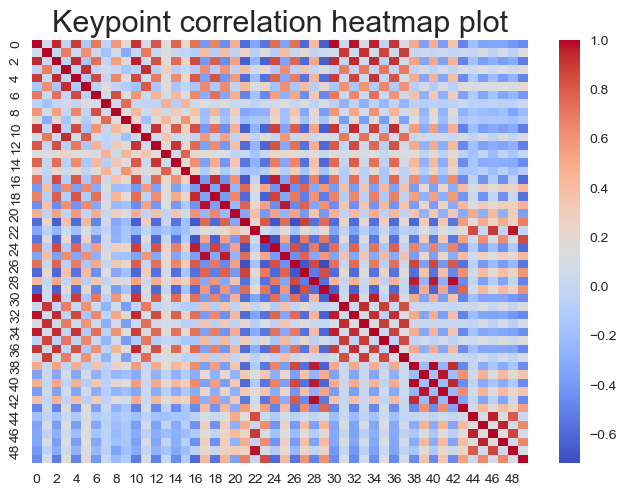

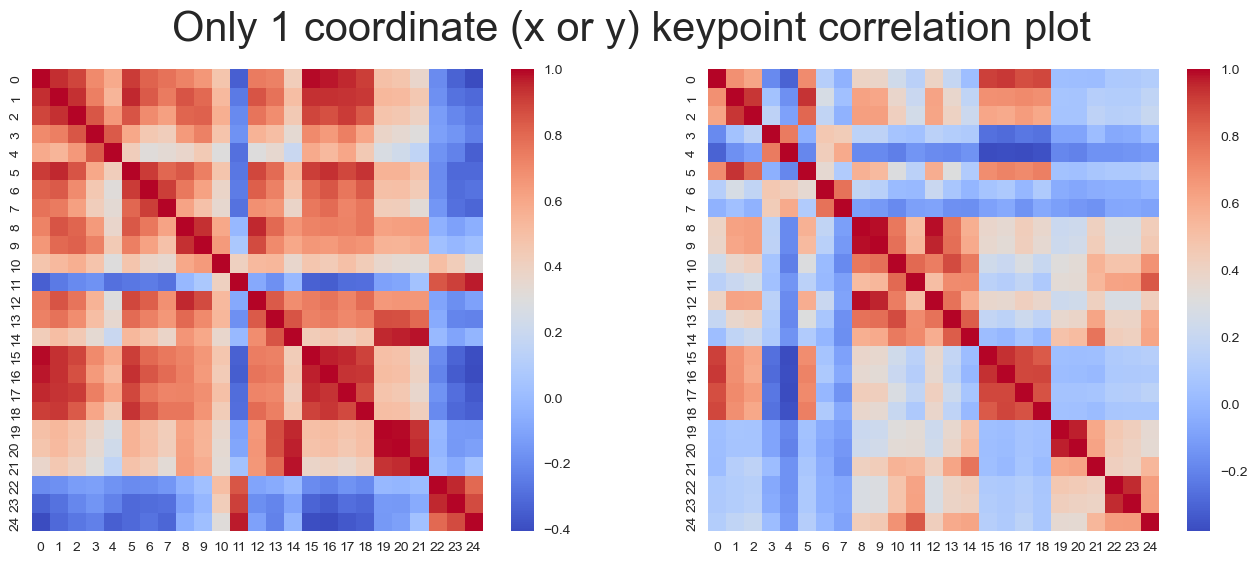

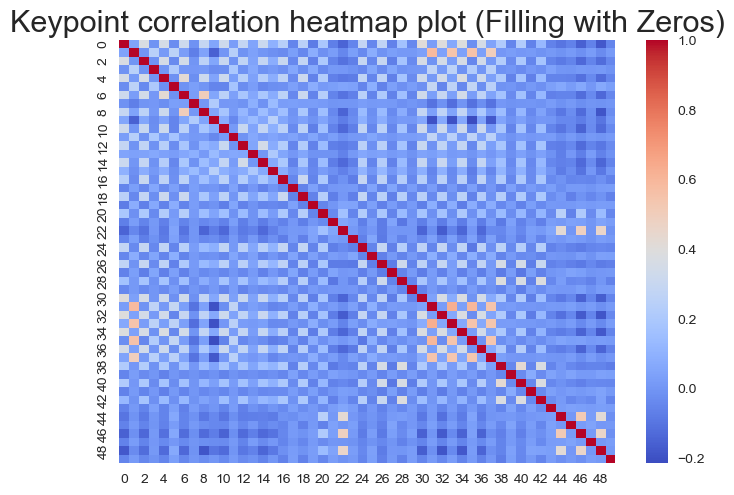

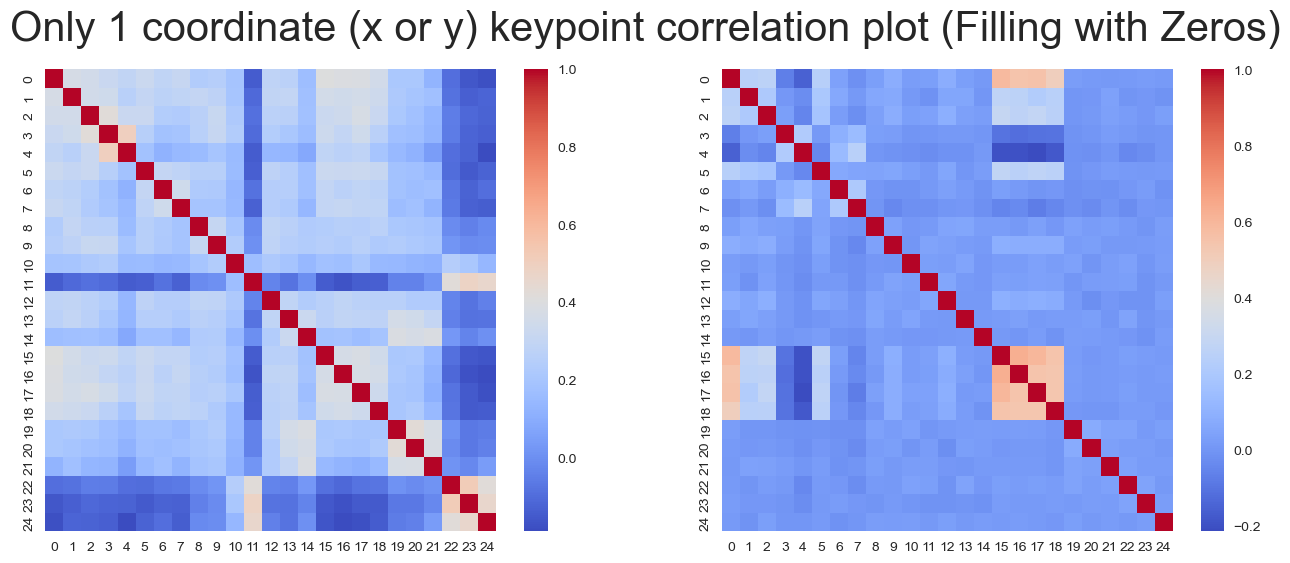

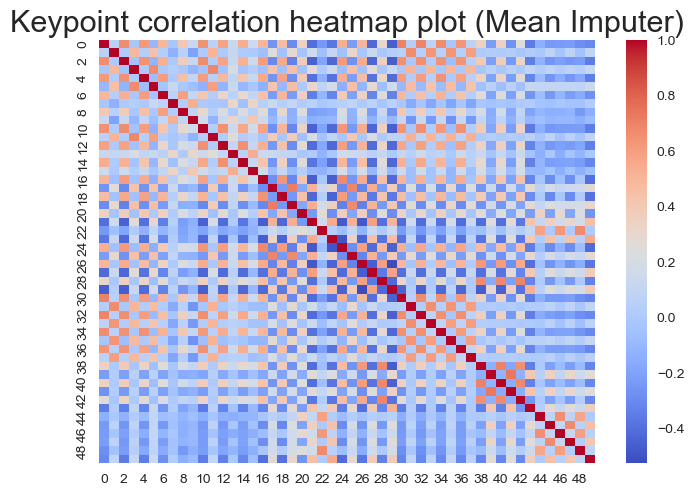

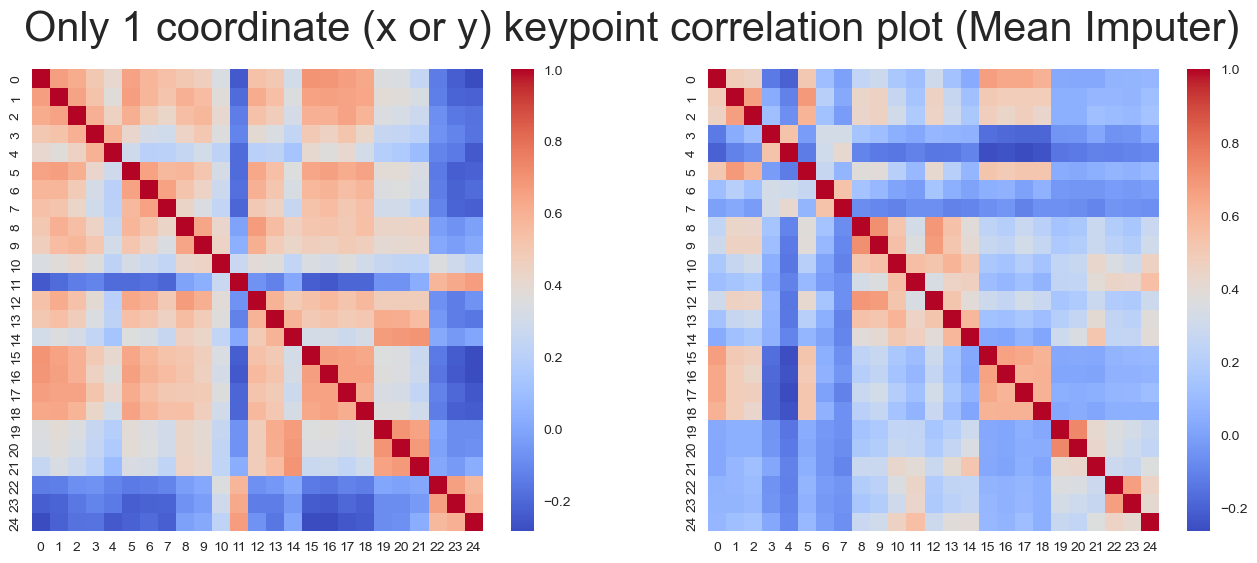

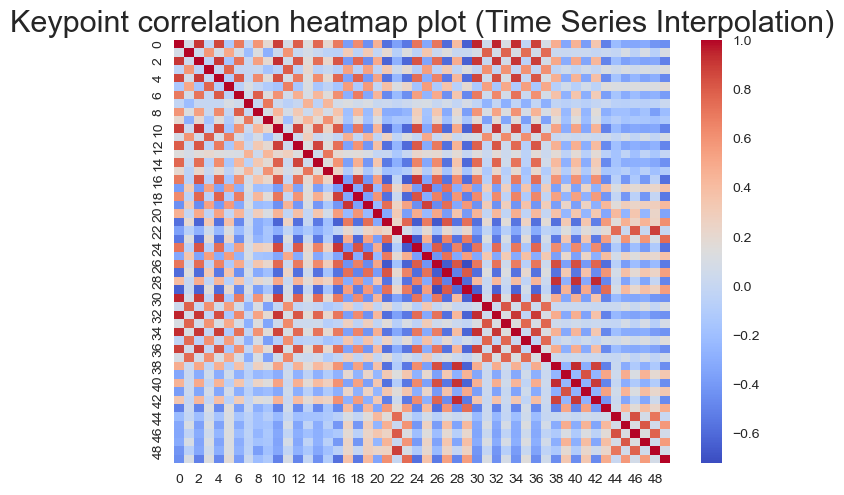

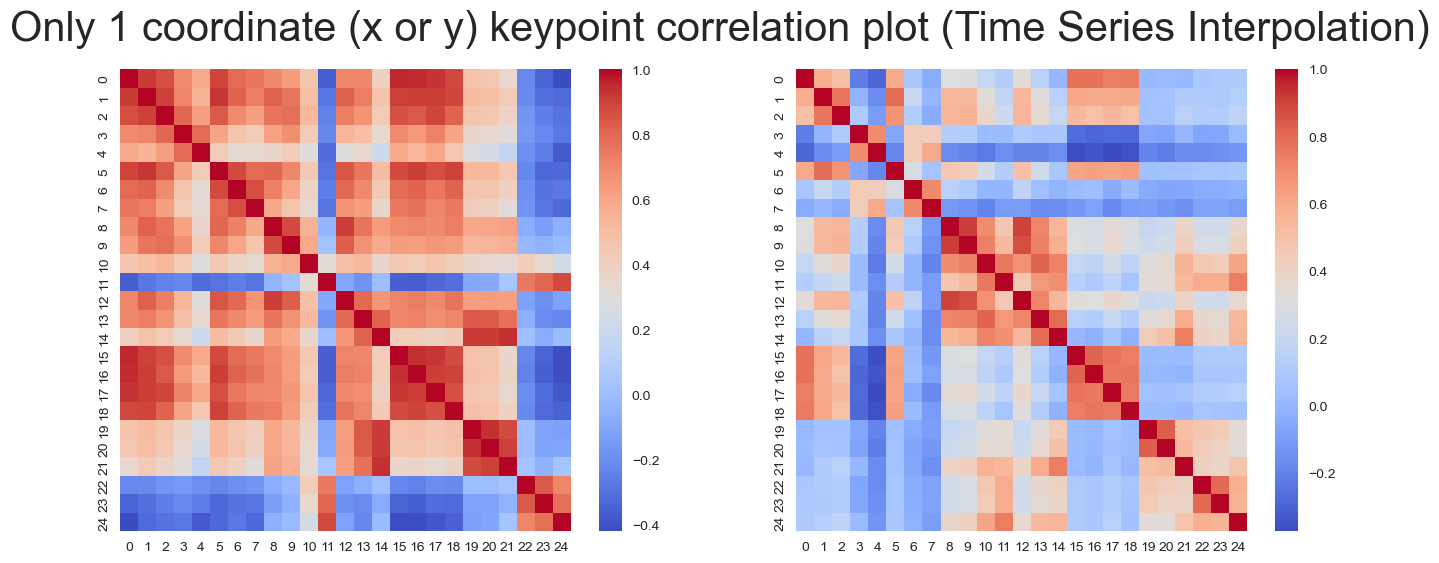

In [103]:
# pre-processing the data: flattening and transposing all of the ground truth poses
GT_poses_reshaped = GT_poses.reshape(-1,50)[:].T

GT_poses_reshaped_only_x = GT_poses.reshape(-1,50)[:,::2].T
GT_poses_reshaped_only_y = GT_poses.reshape(-1,50)[:,1::2].T

# Generating the correlation matrix
plt.title('Keypoint correlation heatmap plot',fontsize=22)
sns.heatmap(np.corrcoef(GT_poses_reshaped),cmap='coolwarm')
plt.show()
### Only x and only y correlation keypoint plots
plt.figure(figsize=(16,6))
plt.suptitle('Only 1 coordinate (x or y) keypoint correlation plot',fontsize=30)
plt.subplot(1,2,1)
sns.heatmap(np.corrcoef(GT_poses_reshaped_only_x),cmap='coolwarm')
plt.subplot(1,2,2)
sns.heatmap(np.corrcoef(GT_poses_reshaped_only_y),cmap='coolwarm')
plt.show();


#Pre-processing the adjusted data
adjusted_data1_reshaped = adjusted_data1.reshape(-1,50)[:].T
adjusted_data1_reshaped_only_x = adjusted_data1.reshape(-1,50)[:,::2].T
adjusted_data1_reshaped_only_y = adjusted_data1.reshape(-1,50)[:,1::2].T

adjusted_data2_reshaped = adjusted_data2.reshape(-1,50)[:].T
adjusted_data2_reshaped_only_x = adjusted_data2.reshape(-1,50)[:,::2].T
adjusted_data2_reshaped_only_y = adjusted_data2.reshape(-1,50)[:,1::2].T

adjusted_data3_reshaped = adjusted_data3.reshape(-1,50)[:].T
adjusted_data3_reshaped_only_x = adjusted_data3.reshape(-1,50)[:,::2].T
adjusted_data3_reshaped_only_y = adjusted_data3.reshape(-1,50)[:,1::2].T

# Generating the correlation matrix for each of the three methods (+ Only x and only y correlation keypoint plots)
plt.title('Keypoint correlation heatmap plot (Filling with Zeros)',fontsize=22)
sns.heatmap(np.corrcoef(adjusted_data1_reshaped),cmap='coolwarm')
plt.show()

plt.figure(figsize=(16,6))
plt.suptitle('Only 1 coordinate (x or y) keypoint correlation plot (Filling with Zeros)',fontsize=30)
plt.subplot(1,2,1)
sns.heatmap(np.corrcoef(adjusted_data1_reshaped_only_x),cmap='coolwarm')
plt.subplot(1,2,2)
sns.heatmap(np.corrcoef(adjusted_data1_reshaped_only_y),cmap='coolwarm')
plt.show();

plt.title('Keypoint correlation heatmap plot (Mean Imputer)',fontsize=22)
sns.heatmap(np.corrcoef(adjusted_data2_reshaped),cmap='coolwarm')
plt.show()

plt.figure(figsize=(16,6))
plt.suptitle('Only 1 coordinate (x or y) keypoint correlation plot (Mean Imputer)',fontsize=30)
plt.subplot(1,2,1)
sns.heatmap(np.corrcoef(adjusted_data2_reshaped_only_x),cmap='coolwarm')
plt.subplot(1,2,2)
sns.heatmap(np.corrcoef(adjusted_data2_reshaped_only_y),cmap='coolwarm')
plt.show();

plt.title('Keypoint correlation heatmap plot (Time Series Interpolation)',fontsize=22)
sns.heatmap(np.corrcoef(adjusted_data3_reshaped),cmap='coolwarm')
plt.show() 

plt.figure(figsize=(16,6))
plt.suptitle('Only 1 coordinate (x or y) keypoint correlation plot (Time Series Interpolation)',fontsize=30)
plt.subplot(1,2,1)
sns.heatmap(np.corrcoef(adjusted_data3_reshaped_only_x),cmap='coolwarm')
plt.subplot(1,2,2)
sns.heatmap(np.corrcoef(adjusted_data3_reshaped_only_y),cmap='coolwarm')
plt.show(); 


In [0]:
#Write reflection here ...

#The above plots show the correlation heatmaps for the ground truth dataset and the three imputed datasets (Filling with Zeros, Mean Imputer, Time Series Interpolation).

# 2. Compare the correlation matrices:    
# - Do any of the imputation methods preserve the original relationships between joints?
# The zero-filling method does not preserve the original relationships well, as it introduces a bias towards zero, distorting the correlations.
# The heatmap still shows a little bit of the original structure, but almost all correlations are weakened and a lot is lost.
# The mean imputer method preserves some of the original relationships, but still distorts them to some extent.
# The heatmap shows more of the original structure compared to zero-filling, but some correlations are still weakened.
# The time series interpolation method preserves the original relationships the best among the three methods.
# The heatmap closely resembles the original ground truth heatmap, indicating that the correlations between joints are well maintained.

# - Does it have any significance whether the original relationship is preserved?
# Yes, preserving the original relationships between joints is significant because it maintains the inherent structure and dependencies in the data.

# 3. Based on the MSE scores, the visual inspection, and the inspection of statistical properties, which imputation method would you chose for the current dataset and why? List at least 5 different reasons for your choice.
# Based on the MSE scores, visual inspection, and statistical properties, I would choose the Time Series Interpolation method for the current dataset.
# Reasons:
# 1. Lowest MSE: The time series interpolation method consistently yields the lowest MSE scores, indicating better performance in reconstructing missing data.
# 2. Visual Accuracy: The adjusted poses visually resemble the ground truth more closely than the other methods, indicating effective reconstruction.
# 3. Preservation of Relationships: The correlation matrix shows that this method preserves the original relationships between joints better than the other methods.
# 4. Temporal Consistency: This method leverages the temporal structure of the data, which is crucial for time series data like skeleton poses.
# 5. Reduced Bias: Unlike zero-filling, which introduces a bias towards zero, time series interpolation provides more realistic estimates for missing values, leading to more accurate analyses and model training.
